# Flat Core verbs — `points`, `polygons`, `choropleth`

The 3-D tier answers the same **Core vocabulary** as every other backend. These three verbs draw on the
**ground plane (`z = 0`)** — they are the *flat* members of a pair whose other half carries height:

| flat (this notebook) | raised sibling |
|---|---|
| `points()` — markers at `z=0` | `point_cloud()` — a `z` per point |
| `polygons()` — flat fill | `extruded_polygons()` — prisms |
| `choropleth()` — flat fill by column | `extruded_polygons(column=, height=)` — classed prisms |

Because they are flat, their 3-D value is the *contrast* with the raised sibling — so every scene below is
viewed **in perspective** (`view('isometric')`, never straight down), and each flat verb is shown next to
the raised one. We use the shipped Rhine vectors (all EPSG:3035) plus a tiny synthetic set.

In [1]:
%matplotlib inline
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import pyvista as pv

pv.OFF_SCREEN = True  # headless: every scene renders to an image, no interactive window

from digitalearth.base.sources import get_source
from digitalearth.three_d import Scene3D

ROOT = Path.cwd()
while not (ROOT / 'examples' / 'data' / 'LisbonElevation.tif').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
DATA = ROOT / 'examples' / 'data'


def show(scene, title=''):
    """Screenshot a Scene3D off-screen and show it inline, asserting the scene area is not blank."""
    img = scene.screenshot()
    bg = img[0, 0].astype(int)
    area = img[: int(img.shape[0] * 0.8)]
    content = (np.abs(area.astype(int) - bg).sum(-1) > 30).mean()
    assert content > 0.01, f'render looks blank: only {content:.1%} differs from the background'
    plt.figure(figsize=(6, 4)); plt.imshow(img); plt.axis('off')
    if title:
        plt.title(title)
    plt.show()


def show_image(img, title=''):
    """Show an already-captured RGB frame (e.g. from a pyvista Plotter) inline."""
    plt.figure(figsize=(7, 4)); plt.imshow(img); plt.axis('off')
    if title:
        plt.title(title)
    plt.show()
import geopandas as gpd
from shapely.geometry import Polygon

## `points()` vs `point_cloud()` — flat markers, then raised by a value

Left: the 34 Rhine gauges as flat markers on the ground (`z=0`). Right: the *same* gauges fed to
`point_cloud()` as an `(x, y, z)` table with `z` set from `discharge` — now the cloud lifts off the plane
and the scene is unmistakably 3-D. (Markers are enlarged so 34 sparse gauges read over the basin's extent.)

C:\python-environments\pixi\envs\digitalearth-4838541935417106159\envs\viz3d\Lib\site-packages\pyogrio\raw.py:200: RuntimeWarning: Several features with id = 5 have been found. Altering it to be unique. This warning will not be emitted anymore for this layer
  return ogr_read(


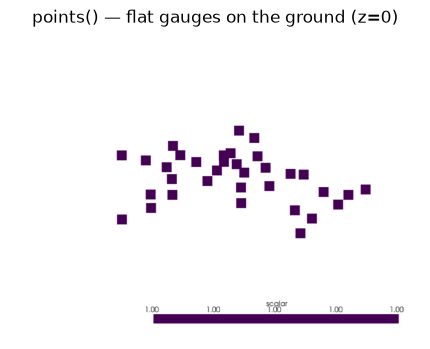

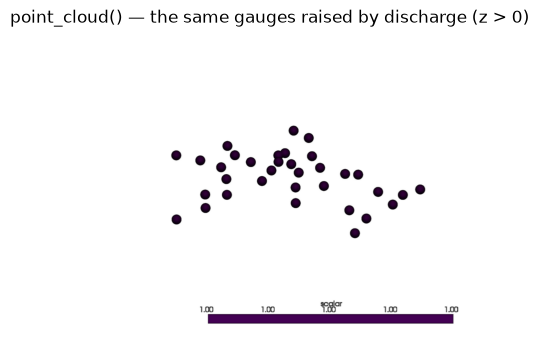

In [2]:
gauges = gpd.read_file(str(DATA / 'rhine_gauges.geojson'))

# flat: markers on the ground plane
scene = Scene3D(off_screen=True)
scene.points(gauges, column='discharge', cmap='viridis', size=55.0)
scene.view('isometric')
show(scene, 'points() — flat gauges on the ground (z=0)')
scene.close()

# raised: the same gauges as an (x, y, z) cloud, z from discharge
xy = np.column_stack([gauges.geometry.x.values, gauges.geometry.y.values])
extent = max(np.ptp(xy[:, 0]), np.ptp(xy[:, 1]))
discharge = gauges['discharge'].fillna(0.0).to_numpy(dtype=float)
z = discharge / (discharge.max() or 1.0) * 0.35 * extent     # scale height to ~35% of the map extent
cloud = np.column_stack([xy, z])
scene = Scene3D(off_screen=True)
scene.point_cloud(cloud, values=discharge, cmap='viridis', size=55.0)
scene.view('isometric')
show(scene, 'point_cloud() — the same gauges raised by discharge (z > 0)')
scene.close()

## `polygons()` vs `extruded_polygons()` — flat fill, then a raised prism

The Rhine basin as a flat fill on the ground, then extruded into a 3-D prism. Same footprint, same scene
orientation — height is the only difference.

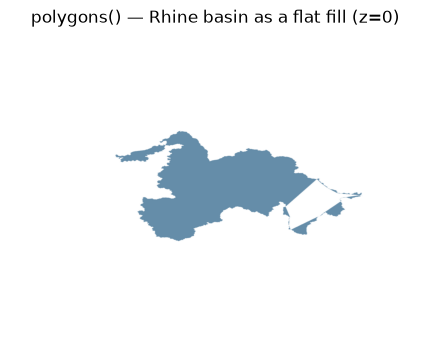

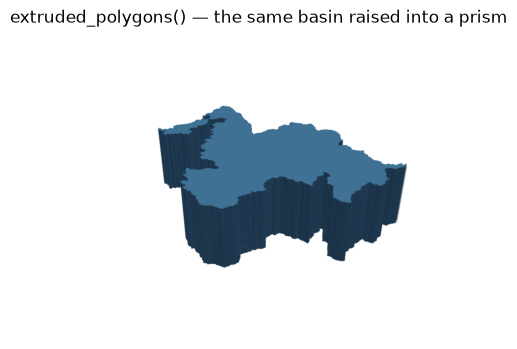

In [3]:
basin = gpd.read_file(str(DATA / 'rhine_basin.geojson'))
bounds = basin.total_bounds
basin_extent = max(bounds[2] - bounds[0], bounds[3] - bounds[1])

scene = Scene3D(off_screen=True)
scene.polygons(basin, color='steelblue', opacity=0.8)
scene.view('isometric')
show(scene, 'polygons() — Rhine basin as a flat fill (z=0)')
scene.close()

scene = Scene3D(off_screen=True)
scene.extruded_polygons(basin, height=0.3 * basin_extent, color='steelblue')
scene.view('isometric')
show(scene, 'extruded_polygons() — the same basin raised into a prism')
scene.close()

## `choropleth()` vs classed extrusion — flat classes, then raised classes

`choropleth` requires a `column` and classifies it (here four synthetic zones by `population`, into
quantiles). The raised sibling is `extruded_polygons` given the same `column` *and* a `height`, so each
class rises as well as recolours. Heights are scaled to the ~2-unit footprint so the towers stay readable.

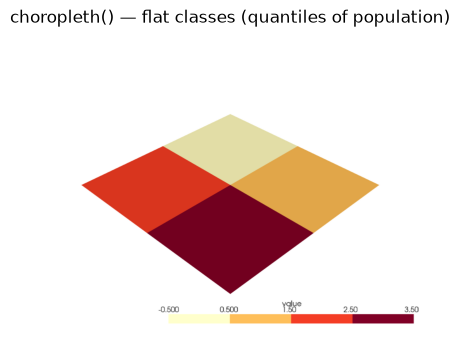

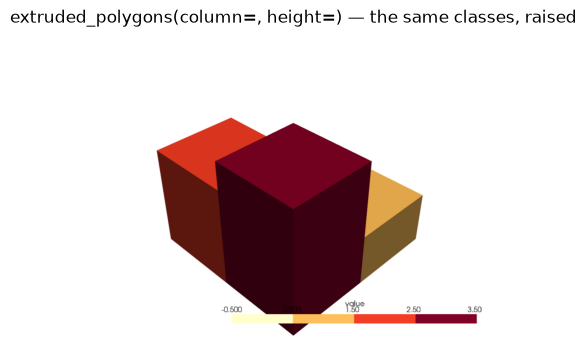

In [4]:
zones = gpd.GeoDataFrame(
    {'population': [12.0, 48.0, 25.0, 61.0], 'height': [12 / 40, 48 / 40, 25 / 40, 61 / 40]},
    geometry=[
        Polygon([(0, 0), (1, 0), (1, 1), (0, 1)]),
        Polygon([(1, 0), (2, 0), (2, 1), (1, 1)]),
        Polygon([(0, 1), (1, 1), (1, 2), (0, 2)]),
        Polygon([(1, 1), (2, 1), (2, 2), (1, 2)]),
    ],
)

scene = Scene3D(off_screen=True)
scene.choropleth(zones, column='population', scheme='quantiles', k=4, cmap='YlOrRd')
scene.view('isometric')
show(scene, 'choropleth() — flat classes (quantiles of population)')
scene.close()

scene = Scene3D(off_screen=True)
scene.extruded_polygons(zones, height='height', column='population', scheme='quantiles', k=4, cmap='YlOrRd')
scene.view('isometric')
show(scene, 'extruded_polygons(column=, height=) — the same classes, raised')
scene.close()

**Recap.** `points`/`polygons`/`choropleth` draw flat on the ground plane — their natural job is to
*annotate* a 3-D scene (markers and footprints beneath terrain, a volume or extruded geometry). When the
data itself carries height, reach for the raised sibling: `point_cloud` for an `(x, y, z)` cloud and
`extruded_polygons` for prisms.